In [1]:
import numpy as np

from pygom import Event, Transition, SimulateOde
import matplotlib.pyplot as plt

# from pygom.simulation.src.simulation.stochastic.api import solve_stochastic

In [ ]:
# Params and states
params = ['beta', 'gamma', 'N']
states = ['S', 'I', 'R']

# Build model
transition_inf = Transition(origin='S', destination='I', transition_type='T', rate='beta*S*I/N')
transition_rec = Transition(origin='I', destination='R', transition_type='T', rate='gamma*I')
model = SimulateOde(state=states, param=params, event=[transition_inf, transition_rec])

# Set params and initial conditions
model.parameters = {'beta': 0.3, 'gamma': 0.25, 'N':10_000}
model.initial_values = ({'S': 9999, 'I': 0.25, 'R': 0}, 0)

# Stochastic solving

First we set up an SIR model with pygom.
The stochastic solver is not yet integrated into pygom class so we extract the necessary attributes and feed them in to the solver.

In [2]:
N = 1e6
R0 = 3.0
gamma = 1/4.0
beta = R0 * gamma

# Params and states
params=['beta', 'gamma', 'N']
states=['S', 'I', 'R']
# states = [('S', (0, 100)), ('I', (0, 1)), ('R', (0, None))]

# Transitions
transition_infection=Transition(origin='S', destination='I', transition_type='T', magnitude='1')
event_infection=Event(transition_list=[transition_infection], rate='beta*S*I/N')

transition_recovery=Transition(origin='I', destination='R', transition_type='T', magnitude='1')
event_recovery=Event(transition_list=[transition_recovery], rate='gamma*I')

event_list = [event_infection, event_recovery]
model=SimulateOde(state=states, param=params, event=event_list)
model.parameters = {"beta": beta, "gamma": gamma, "N":N}

# Initial conditions
i0 = 1
x0 = np.array([N-i0, i0, 0])

model.initial_values = (x0, 0)

In [ ]:
sol = model.solve_deterministic(100.0)

In [31]:
x_aug = np.concatenate( [x0, np.zeros(2)] )
t = 0.0

n_state = 3

x = x_aug[:n_state]

# change in states
jac_x = model.jacobian(x, t)

# transition occurances
jac_t = model.rates_jacobian(x, t)

jac_aug = np.zeros( (len(x_aug), len(x_aug)) )

jac_aug[:n_state, :n_state] = jac_x
jac_aug[n_state:, :n_state] = jac_t


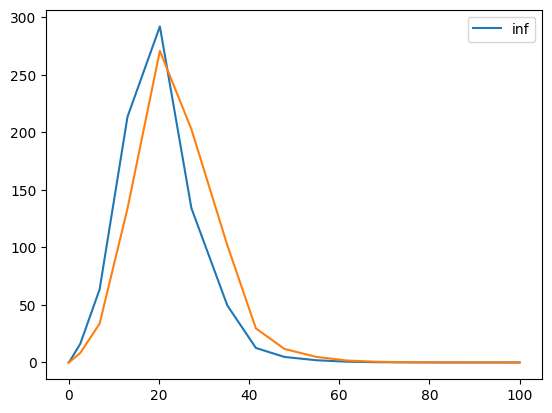

In [12]:
sol = model.solve_deterministic(100.0)

plt.plot(sol.result.t[1:], sol.result.jumps[:,0], label="inf")
plt.plot(sol.result.t[1:], sol.result.jumps[:,1])
plt.legend()
plt.show()

In [3]:
# from dask.distributed import Client
# client = Client(n_workers=4, threads_per_worker=1)

# outs = model.solve_stochastic(
#     t = 100,
#     method="fixed_tau", tau=.1, iteration=50,
#     parallel=True, parallel_backend="dask", client=client, seed=0)

# for out in outs:
#     plt.plot(out.result.t, out.result.x[:, 1], alpha=0.2, color="black")
# plt.plot(det.result.t, det.result.x[:, 1], color="red")
# plt.show()

In [4]:
# Recovery rate, gamma
gamma_var = (gamma / 10)**2  # Set the standard deviation to be 1/10th of the mean value
gamma_shape = (gamma**2) / gamma_var
gamma_rate = gamma / gamma_var

# Infectivity parameter, beta
beta_var = (beta / 10)**2  # Set the standard deviation to be 1/10th of the mean value
beta_shape = (beta**2) / beta_var
beta_rate = beta / beta_var

from pygom.utilR import rgamma
random_param_set = dict()  # container for random param set
random_param_set['gamma'] = (rgamma, {'shape': gamma_shape, 'rate': gamma_rate})
random_param_set['beta'] = (rgamma, {'shape': beta_shape, 'rate': beta_rate})
random_param_set['N'] = N

model.parameters = random_param_set

initialising rng
initialising rng
initialising rng
initialising rng


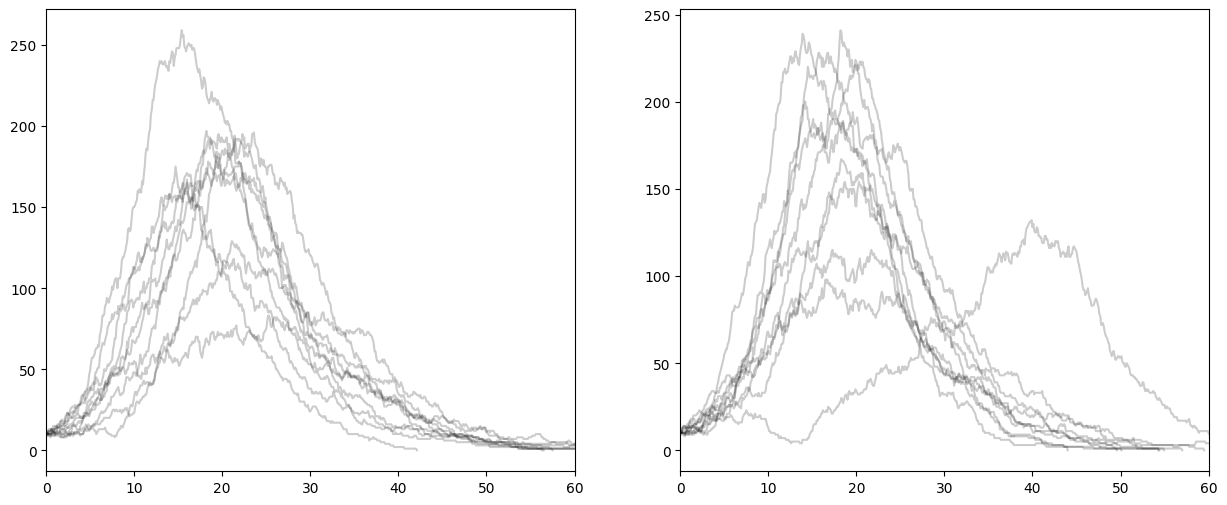

In [5]:
# model.parameters = {"beta": beta, "gamma": gamma, "N":N}
model.parameters = random_param_set

niter = 10

fig, ax = plt.subplots(1, 2, figsize=(15,6))

outs = model.solve_stochastic(
    t=100,
    method="fixed_tau", tau=.1,
    iteration=niter,
    seed=1)

for out in outs:
    ax[0].plot(out.result.t, out.result.x[:, 1], alpha=0.2, color="black")
# ax[0].plot(det.result.t, det.result.x[:, 1], color="red")

outs = model.solve_stochastic(
    t=100,
    method="fixed_tau", tau=.1,
    iteration=niter,
    seed=1)

for out in outs:
    ax[1].plot(out.result.t, out.result.x[:, 1], alpha=0.2, color="black")
# ax[1].plot(det.result.t, det.result.x[:, 1], color="red")

for axes in ax:
    # axes.set_ylim(0, 2500)
    axes.set_xlim(0, 60)

plt.show()

[0.9999, 0.0001, 0]
-4.9995000000000005e-05
1.666166666666667e-05
3.3333333333333335e-05
[-4.99950000e-05  1.66616667e-05  3.33333333e-05]


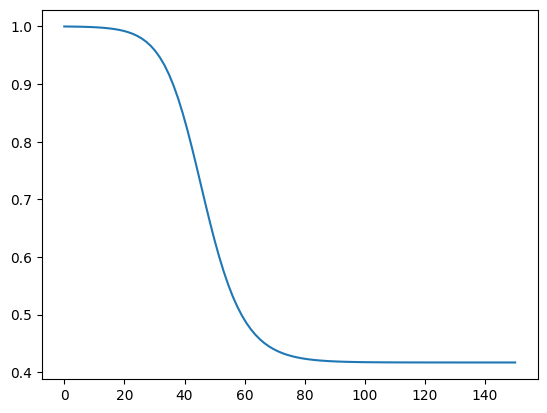

In [ ]:
from pygom import SquareLoss, NormalLoss
from pygom.model import common_models
from pygom import approximate_bayesian_computation as pgabc

# define the model and parameters
beta = 0.5
gamma = 1.0/3.0
ode = common_models.SIR_norm({'beta':beta, 'gamma':gamma})

# the initial state, normalized to one
# i0=1.27e-6
i0=1e-4
x0 = [1-i0, i0, 0]
# set the time sequence that we would like to observe
t = np.linspace(0, 150, 100)
ode.initial_values = (x0, t[0])
# find the solution
solution = ode.integrate(t[1::])

print(x0)
print(- beta * x0[0] * x0[1])
print(beta * x0[0] * x0[1] - gamma * x0[1])
print(gamma * x0[1])
print(ode.ode(x0, 0.0))

plt.plot(t, solution[:,0])
plt.show()

In [ ]:

# what the posterior median estimates should be close to
target = np.array([beta, gamma])
        
# y = solution[1::, 1:3]

y = solution[1::, 1]

theta = np.array([0.4, 0.2])
# sql = SquareLoss(theta, ode, x0, t[0], t[1::], y, ['I', 'R'])
# sql = SquareLoss(theta, ode, x0, t[0], t[1::], y, ['I'])
sql = NormalLoss(theta, ode, x0, t[0], t[1::], y, ['I'])

N = 10
cost = np.zeros( (N, N) )
betas = np.linspace(0.2, 0.6, N)
gammas = np.linspace(0.2, 0.6, N)

for i in range(N):
    for j in range(N):
        theta = np.array([betas[i], gammas[j]])
        cost[i][j] = sql.cost(theta)

plt.figure(figsize=(6, 5))
plt.imshow(cost, extent=[gammas.min(), gammas.max(), betas.min(), betas.max()],
           origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label="Cost")
plt.xlabel("gamma")
plt.ylabel("beta")
plt.title("Loss function")
plt.scatter(x=gamma, y=beta, color="red")
plt.show()


[0.9999, 0.0001, 0]
-4.9995000000000005e-05
1.666166666666667e-05
3.3333333333333335e-05
[-4.99950000e-05  1.66616667e-05  3.33333333e-05]
[[-5.00000000e-05 -4.99950000e-01  0.00000000e+00]
 [ 5.00000000e-05  1.66616667e-01  0.00000000e+00]
 [ 0.00000000e+00  3.33333333e-01  0.00000000e+00]]


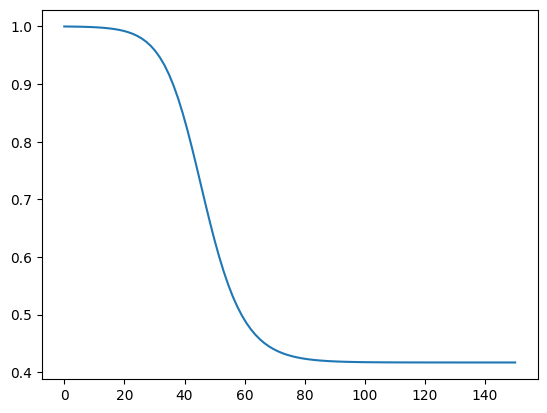

0.4170780216271337


In [8]:
from pygom import SquareLoss, NormalLoss
from pygom.model import common_models
from pygom import approximate_bayesian_computation as pgabc

# define the model and parameters
beta = 0.5
gamma = 1.0/3.0
ode = common_models.SIR_norm({'beta':beta, 'gamma':gamma})

# the initial state, normalized to one
# i0=1.27e-6
i0=1e-4
x0 = [1-i0, i0, 0]
# set the time sequence that we would like to observe
t = np.linspace(0, 150, 100)
ode.initial_values = (x0, t[0])
# find the solution
solution = ode.integrate(t[1::])

print(x0)
print(- beta * x0[0] * x0[1])
print(beta * x0[0] * x0[1] - gamma * x0[1])
print(gamma * x0[1])

print(ode.ode(x0, 0.0))
print(ode.jacobian(x0, 0.0))

plt.plot(t, solution[:,0])
plt.show()

print(solution[-1, 0])

[[-5.00000000e-05 -4.99950000e-01  0.00000000e+00]
 [ 5.00000000e-05  1.66616667e-01  0.00000000e+00]
 [ 0.00000000e+00  3.33333333e-01  0.00000000e+00]]


[[-5.00000000e-05 -4.99950000e-01  0.00000000e+00]
 [ 5.00000000e-05  1.66616667e-01  0.00000000e+00]
 [ 0.00000000e+00  3.33333333e-01  0.00000000e+00]]


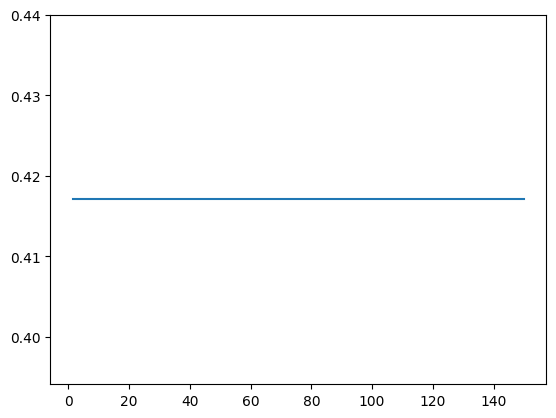

In [9]:
# print(x0)
# print(- beta * x0[0] * x0[1])
# print(beta * x0[0] * x0[1] - gamma * x0[1])
# print(gamma * x0[1])

# print(ode.ode(x0, 0.0))

print(ode.jacobian(x0, 0.0))

print("\n")

print(ode.jacobian.T(0.0, x0))

from pygom.model import ode_utils

solution = ode_utils.integrateFuncJac(ode.ode.T,
                                      ode.jacobian.T,
                                      x0, t[0],
                                      t[1::],
                                      full_output=False,
                                      method=ode._intName)



# solution[0]

plt.plot(t[1:], solution[:,0])
plt.show()

In [ ]:


# setting the parameters in the inference
parameters = [pgabc.Parameter('beta', 'unif', 0, 1.0, logscale=False),
                pgabc.Parameter('gamma', 'unif', 0, 1.0, logscale=False)]

# creating the loss and abc objects
sir_obj = pgabc.create_loss("SquareLoss", parameters, ode, x0, t[0],
                            t[1::], y, ['I', 'R'])
sir_abc = pgabc.ABC(sir_obj, parameters)

# getting the posterior sample
sir_abc.get_posterior_sample(N=100, tol=np.inf, G=20, q=0.5)
out = sir_abc.plot_posterior_histograms()

In [51]:
np.median(sir_abc.res, axis=0)

array([0.44417385, 0.35864879])

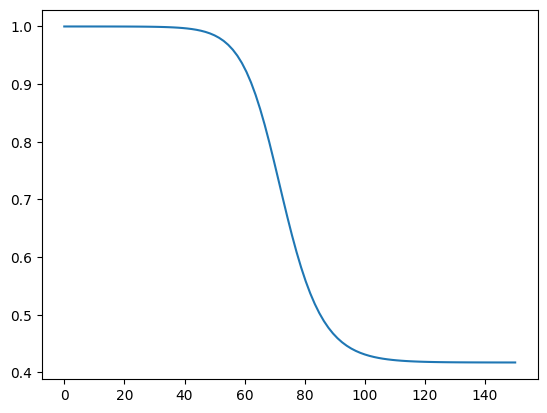

In [52]:
plt.plot(t, solution[:,0])

C:\Users\Joseph.Gibson\OneDrive - UK Health Security Agency\pygom\src\pygom\approximate_bayesian_computation\approximate_bayesian_computation.py:635: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


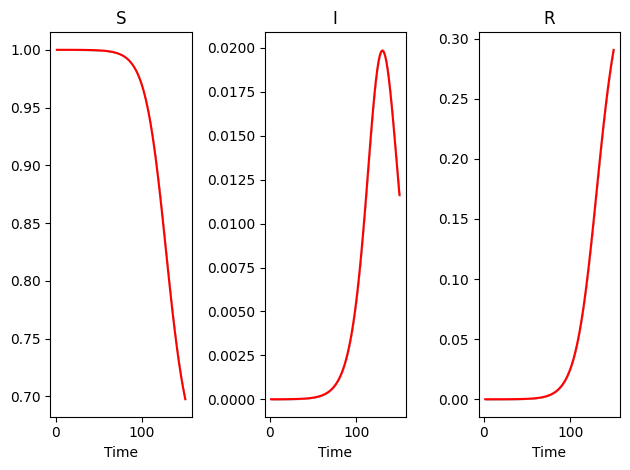

In [53]:
sir_abc.plot_pointwise_predictions();

In [29]:
np.median(sir_abc.res, axis=0)

array([0.444172  , 0.35864818])

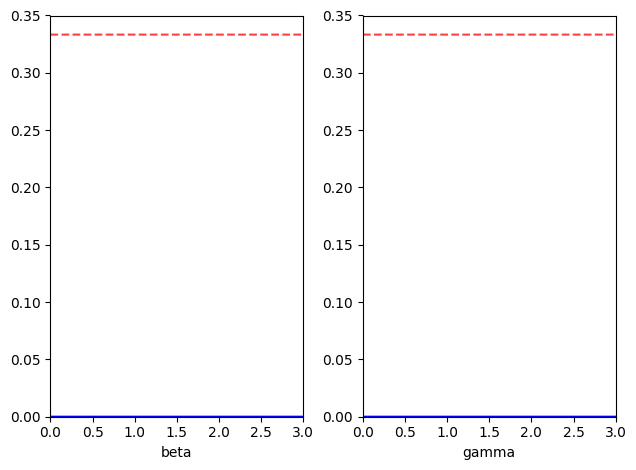

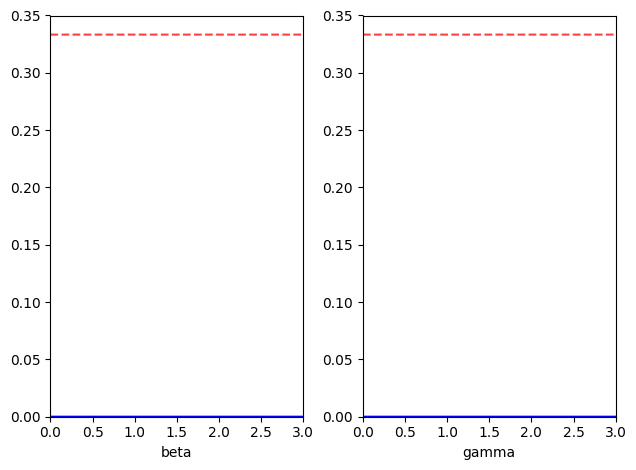

In [28]:
sir_abc.continue_posterior_sample(N=100, tol=sir_abc.next_tol, G=19, q=0.5)
sir_abc.plot_posterior_histograms()

In [19]:

# Functions to input to solvers
transition_func = model.event_rate_vector           # rates at which events occur
state_change_mat = model.state_change_matrix        # state change as a result of each event
transition_mean_func = model.transition_mean        # (for adaptive tau) mean change of rates
transition_var_func = model.transition_variance     # (for adaptive tau) variance of change
ode_func = model.ode

## ################################
## SEIR model instead if interested
## ################################

# N = 1e5
# R0 = 1.3
# alpha = 1/2.0
# gamma = 1/4.0
# beta = R0 * gamma

# # Initial conditions
# i0 = 10
# x0 = np.array([N-i0, 0, i0, 0])

# # Params and states
# params=['beta', 'alpha', 'gamma', 'N']
# states=['S', 'E', 'I', 'R']

# # State Limits
# xlims = np.asarray([(0, N), (0, N), (0, N), (0, N)], dtype=object)
# mins = np.array([lim[0] if lim[0] is not None else -np.inf for lim in xlims])
# maxs = np.array([lim[1] if lim[1] is not None else np.inf for lim in xlims])

# # Transitions
# transition_infection=Transition(origin='S', destination='E', transition_type='T', magnitude='1')
# event_infection=Event(transition_list=[transition_infection], rate='beta*S*I/N')

# transition_progress=Transition(origin='E', destination='I', transition_type='T', magnitude='1')
# event_progress=Event(transition_list=[transition_progress], rate='alpha*E')

# transition_recovery=Transition(origin='I', destination='R', transition_type='T', magnitude='1')
# event_recovery=Event(transition_list=[transition_recovery], rate='gamma*I')

# model=SimulateOde(state=states, param=params, event=[event_infection, event_progress, event_recovery])
# model.parameters = {"beta": beta, "alpha": alpha, "gamma": gamma, "N":N}

# # Functions to input to solvers
# transition_func = model.event_rate_vector
# state_change_mat = model.state_change_matrix
# transition_mean_func = model.transition_mean
# transition_var_func = model.transition_variance

We need to select what stepper to use and perhaps provide parameters specific to that method. 

In [20]:
from pygom.simulation.src.simulation.stochastic.config_api import build_config

In [21]:
# algo = build_config(method="tau_fixed", checker="forbidden_state")

# algo = build_config("tau_fixed", tau=0.1, refiner="prob")

# algo = build_config("cao2006", epsilon=0.02, f_mu=transition_mean_func, f_var=transition_var_func)

In [22]:
from pygom.simulation.src.simulation.stochastic.config import TauConfig, FixedTauConfig, Cao2006TauConfig
from pygom.simulation.src.simulation.stochastic.config import ExactConfig, DirectMethodConfig, FirstReactionMethodConfig

# Adaptive tau leap
algo_tau_adapt = TauConfig(method=Cao2006TauConfig(epsilon=0.03))

# Fixed tau leap
algo_tau_fixed = TauConfig(method=FixedTauConfig(tau=0.1))

# Direct reaction method
algo_direct = ExactConfig(method=DirectMethodConfig())

TypeError: Cao2006TauConfig.__init__() missing 2 required positional arguments: 'transition_mean_func' and 'transition_var_func'

Tau leap algorithms also have options on:

1) Preemptively reducing tau if there is sufficient risk of an illegal step

In [ ]:
from pygom.simulation.src.simulation.stochastic.config import ProbabilisticRefinerConfig

# e.g. refine the step size if there is a >0.05 chance of an illegal step occuring.
#      abandon if sufficiently small step size not found after 10 attempts 

algo_tau_adapt = TauConfig(
    method=FixedTauConfig(tau=0.1),
    checker=CriticalReactionConfig(),
    refiner=ProbabilisticRefinerConfig(
        max_retries=10,
        acceptable_prob_misstep=0.05),
    retry_max=10, tau_rescale=0.5)

2) Checking if a step is legal

In [ ]:
from pygom.simulation.src.simulation.stochastic.config import CriticalReactionConfig

# e.g. check that transitions do not occur more than they possibly can (this
#      is different from checking that the states are legal)

algo_tau_adapt = TauConfig(
    method=FixedTauConfig(tau=0.1),
    checker=CriticalReactionConfig()
    )

3) Retrying a step if it resulted in an illegal state

In [ ]:
# e.g. retry an illegal step at most 10 times by shortening the time step
#      by a factor 0.5 each time

algo_tau_adapt = TauConfig(
    method=FixedTauConfig(tau=0.1),
    retry_max=10, tau_rescale=0.5
    )

# # Now lets reset to default ....
# algo_tau_adapt = TauConfig(method=Cao2006TauConfig(epsilon=0.03))

# METHODS = {
#     'Fixed': FixedTauConfig,
#     'Cao2006': Cao2006TauConfig,
#     'Direct': DirectMethodConfig,
#     'FirstReaction': FirstReactionMethodConfig
# }

# FAMILIES = {
#     'Fixed': TauConfig,
#     'Cao2006': TauConfig,
#     'Direct': ExactConfig,
#     'FirstReaction': ExactConfig
# }

# REFINERS = {
#     'No': NoRefinerConfig,
#     'Probabilistic': ProbabilisticRefinerConfig
# }

# def build_config(*, method, **options):

#     if method in METHODS:
#         family = FAMILIES[method]
#         method = METHODS[method]

#         family["method"] = method(**options)
#     else:
#         raise ValueError(f"`method` must be one of {METHODS}.")
    
#     if isinstance(family, TauConfig):
#         family()
    
    


In [ ]:
from pygom.simulation.src.simulation.api import solve_stochastic

sim = solve_stochastic(x0, tmax, ode_eqns, state_matrix, limits, method = , options)

Solving functionality forms its own separate package.

In future, we would want some interface between pygom and the solver begind the scenes which is called by the user as before via something like model.solve().

For this example we pass everything to the solver directly.

In [ ]:
# Initial conditions
i0 = 10
x0 = np.array([N-i0, i0, 0])

# Solve stochastic time evolution
sim = solve_stochastic(
    x0=x0,
    t_max=10000,                                    # set some large value so that max time doesn't cut simulation short (proceed_if_rates_zero must be False)
    ode_eqns=transition_func,
    state_change_mat=state_change_mat,
    x_min=mins, x_max=maxs,
    config=algo_tau_fixed,                          # stepper method (tau fixed / tau adaptive / exact direct / exact first etc....) plus relevant params
    perf=True,                                      # output performance diagnostics
    proceed_if_rates_zero=False,                    # stop the simulation when all rates = 0 (epidemic has ended)
    transition_mean_func=transition_mean_func,
    transition_var_func=transition_var_func
)

In [ ]:
sim.result.jumps[:, 1]

array([0, 0, 0, ..., 0, 0, 1], shape=(1572,), dtype=int32)

In [ ]:
from pygom.simulation.src.simulation.api import solve_stoch

# Initial conditions
i0 = 10
x0 = np.array([N-i0, i0, 0])

# Solve stochastic time evolution
sim = solve_stoch(
    x0=x0,
    t=np.linspace(0, 100, 10),                                    # set some large value so that max time doesn't cut simulation short (proceed_if_rates_zero must be False)
    ode_eqns=transition_func,
    state_change_mat=state_change_mat,
    x_min=mins, x_max=maxs,
    n_trans = 2,
    config=algo_tau_fixed,                          # stepper method (tau fixed / tau adaptive / exact direct / exact first etc....) plus relevant params
    perf=True,                                      # output performance diagnostics
    proceed_if_rates_zero=False,                    # stop the simulation when all rates = 0 (epidemic has ended)
    transition_mean_func=transition_mean_func,
    transition_var_func=transition_var_func
)

C:\Users\Joseph.Gibson\OneDrive - UK Health Security Agency\pygom\src\pygom\simulation\src\simulation\post_processing.py:121: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  density = np.divide(jumps[:, i], dt, where=dt>0)


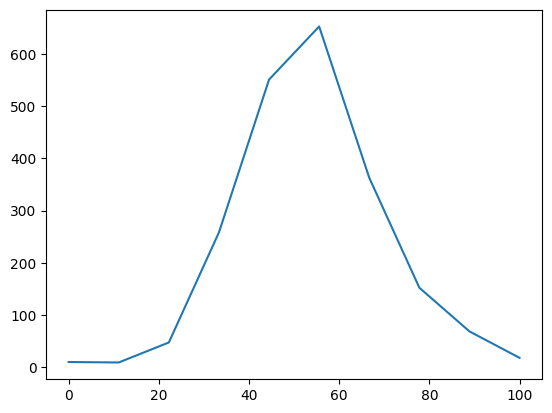

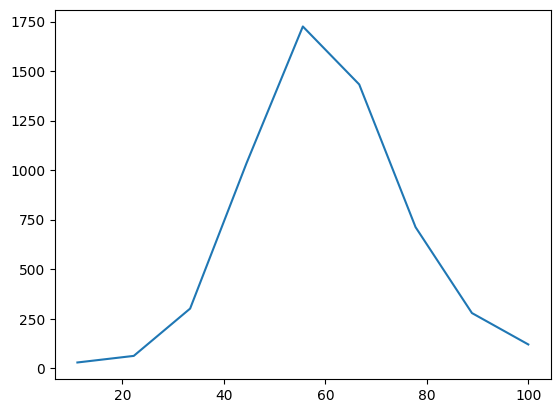

In [ ]:
plt.plot(sim.result.t, sim.result.x[:,1])
plt.show()

plt.plot(sim.result.t[1:], sim.result.jumps[:,1])
plt.show()

We can examine the outputs (there are post processing functions to bin the outputs and take snapshots etc but we'll skip for now).

First of all, since we selected perf=True, we can assess the performance

In [ ]:
sim.performance

PerformanceMetrics(wall_time_seconds=0.0387672999931965, cpu_time_seconds=0.03125)

We can see any diagnostic output, e.g. how many failed steps, did the simulation end prematurely

In [ ]:
sim.diag

TauLeapDiagnostics(zero_rate_termination=False, n_failed_step=0)

We can remind ourselves of what solver configuration we used

In [ ]:
sim.config

TauConfig(method=FixedTauConfig(tau=0.1), checker=CriticalReactionConfig(), refiner=NoRefinerConfig(), retry_max=10, tau_rescale=0.5)

And, of course, see the simualtion results

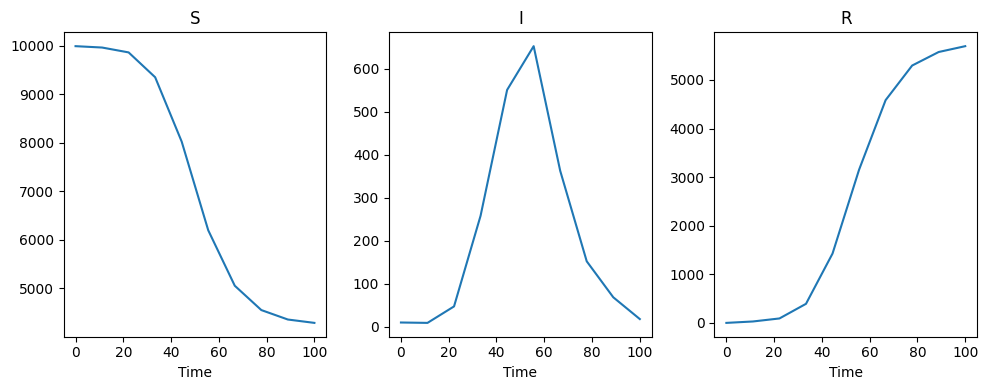

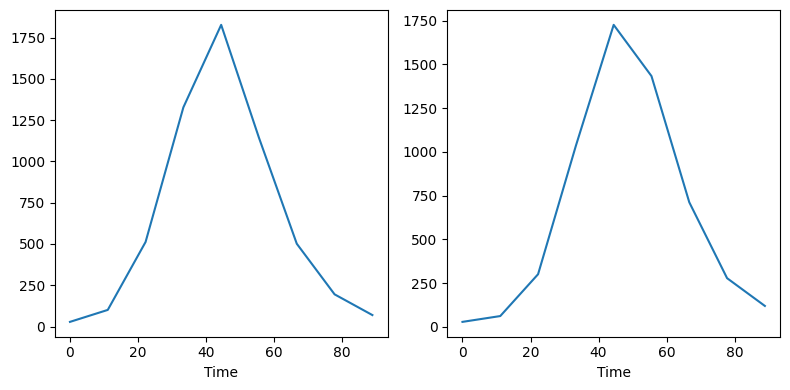

In [ ]:
fig, ax = plt.subplots(1, 3, figsize = (10, 4) )

t = sim.result.t
tmin = t[:-1]

for i in range(len(states)):
    ax[i].plot(t, sim.result.x[:,i])
    ax[i].set_xlabel("Time")
    ax[i].set_title(states[i])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize = (8, 4) )
for i in range(len(event_list)):
    ax[i].plot(tmin, sim.result.jumps[:,i])
    ax[i].set_xlabel("Time")
plt.tight_layout()
plt.show()

We solve with the direct reaction method:

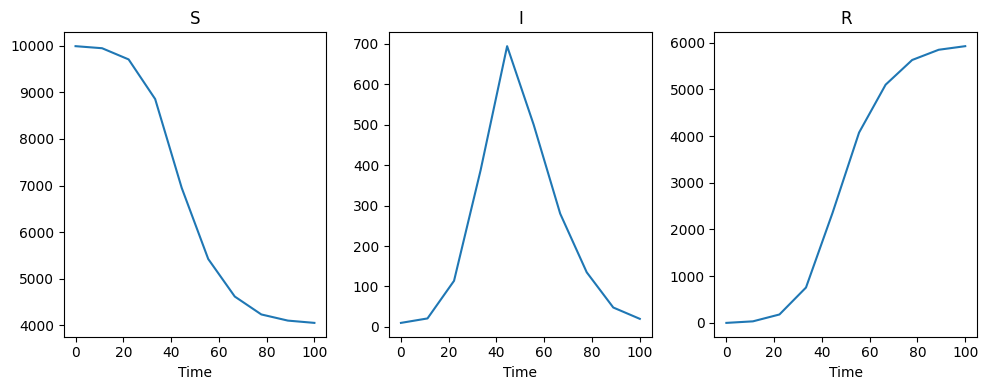

In [ ]:
sim_direct = solve_stochastic(
    x0=x0,
    # t=10000.0,                                    # set some large value so that max time doesn't cut simulation short (proceed_if_rates_zero must be False)
    t = np.linspace(0, 100, 10),
    ode_eqns=transition_func,
    state_change_mat=state_change_mat,
    x_min=mins, x_max=maxs,
    n_trans=2,
    config=algo_direct,                          # stepper method (tau fixed / tau adaptive / exact direct / exact first etc....) plus relevant params
    perf=True,                                      # output performance diagnostics
    transition_mean_func=transition_mean_func,
    transition_var_func=transition_var_func
)

fig, ax = plt.subplots(1, 3, figsize = (10, 4) )

for i in range(len(states)):
    ax[i].plot(sim_direct.result.t, sim_direct.result.x[:,i])
    ax[i].set_xlabel("Time")
    ax[i].set_title(states[i])
plt.tight_layout()
plt.show()

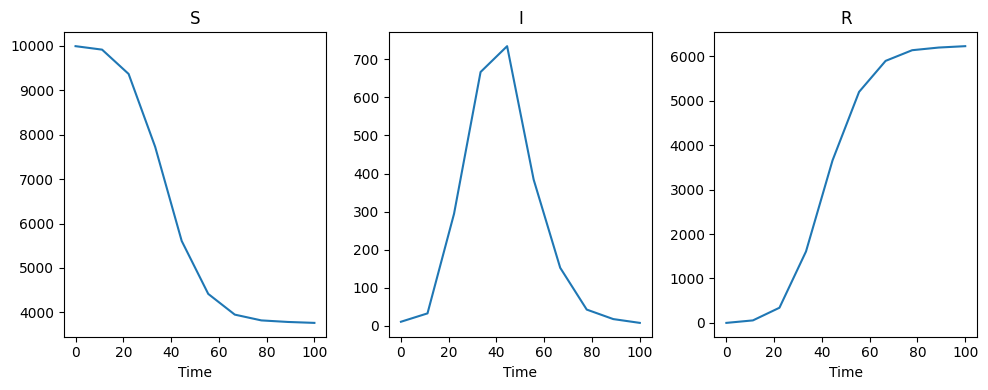

In [ ]:
sim_direct = solve_stochastic(
    x0=x0,
    # t=10000.0,                                    # set some large value so that max time doesn't cut simulation short (proceed_if_rates_zero must be False)
    t=np.linspace(0, 100, 10),
    ode_eqns=transition_func,
    state_change_mat=state_change_mat,
    x_min=mins, x_max=maxs,
    n_trans=2,
    config=algo_direct,                          # stepper method (tau fixed / tau adaptive / exact direct / exact first etc....) plus relevant params
    perf=True,                                      # output performance diagnostics
    transition_mean_func=transition_mean_func,
    transition_var_func=transition_var_func
)

fig, ax = plt.subplots(1, 3, figsize = (10, 4) )

for i in range(len(states)):
    ax[i].plot(sim_direct.result.t, sim_direct.result.x[:,i])
    ax[i].set_xlabel("Time")
    ax[i].set_title(states[i])
plt.tight_layout()
plt.show()

And adaptive tau

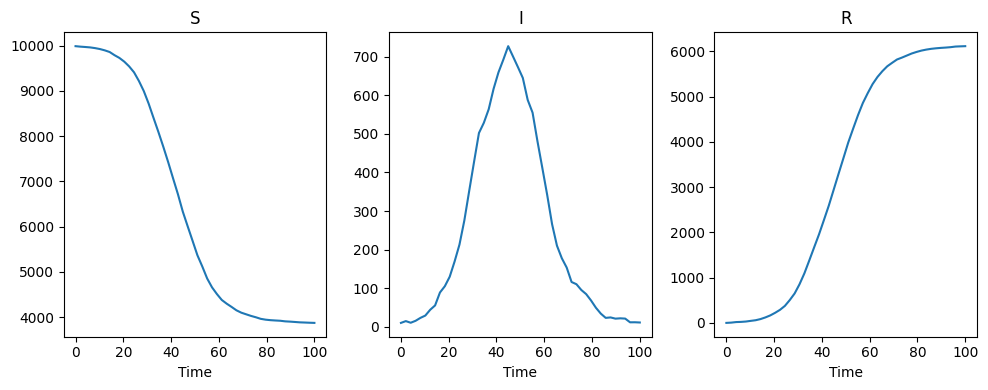

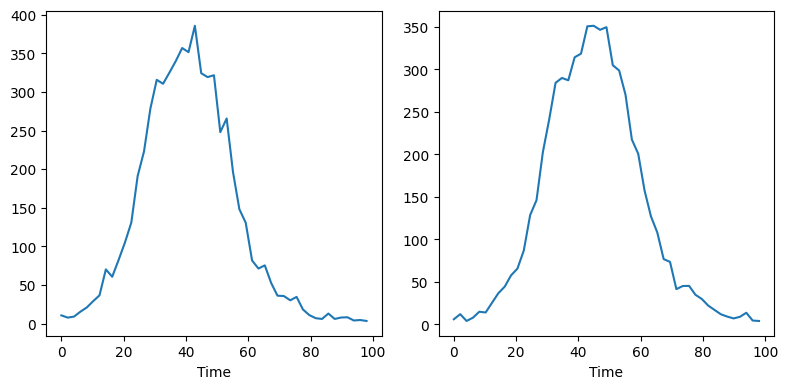

In [ ]:
sim_adapt = solve_stoch(
    x0=x0,
    t=np.linspace(0, 100, 50),                                    # set some large value so that max time doesn't cut simulation short (proceed_if_rates_zero must be False)
    ode_eqns=transition_func,
    state_change_mat=state_change_mat,
    x_min=mins, x_max=maxs,
    n_trans = 2,
    config=algo_tau_adapt,                          # stepper method (tau fixed / tau adaptive / exact direct / exact first etc....) plus relevant params
    perf=True,                                      # output performance diagnostics
    proceed_if_rates_zero=False,                    # stop the simulation when all rates = 0 (epidemic has ended)
    transition_mean_func=transition_mean_func,
    transition_var_func=transition_var_func
)

fig, ax = plt.subplots(1, 3, figsize = (10, 4) )

t = sim_adapt.result.t
tmin = t[:-1]

for i in range(len(states)):
    ax[i].plot(t, sim_adapt.result.x[:,i])
    ax[i].set_xlabel("Time")
    ax[i].set_title(states[i])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize = (8, 4) )
for i in range(len(event_list)):
    ax[i].plot(tmin, sim_adapt.result.jumps[:,i])
    ax[i].set_xlabel("Time")
plt.tight_layout()
plt.show()

Deterministic

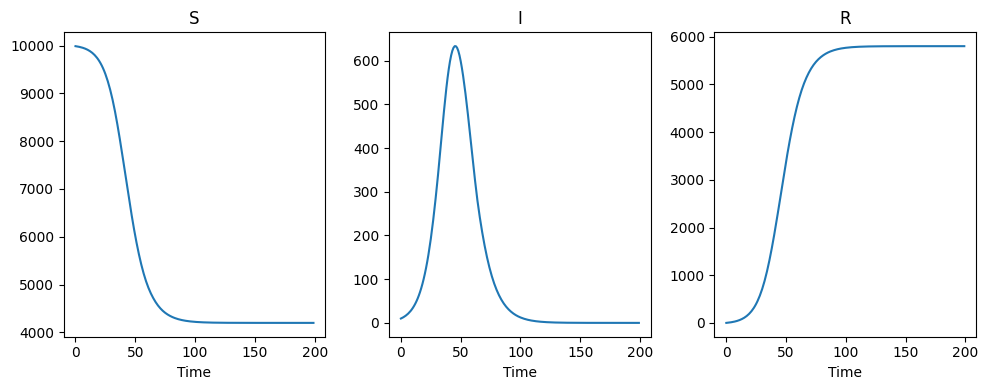

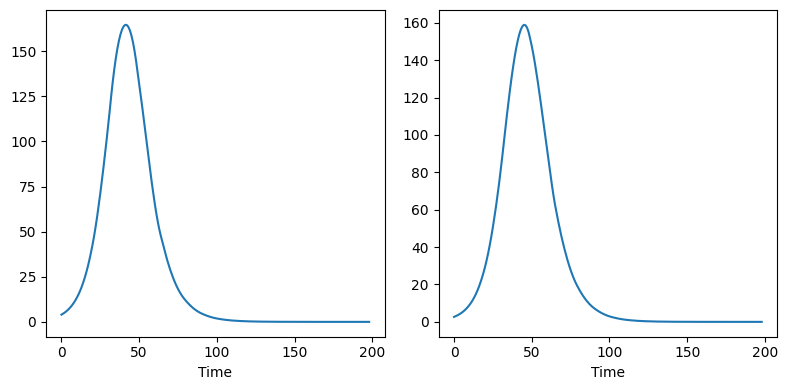

In [ ]:
# from pygom.simulation.src.simulation.deterministic.api import solve_deterministic

from pygom.simulation.src.simulation.api import solve_det

tmax = 200
t_eval = np.arange(0, tmax)

sim_det = solve_det(
    x0=x0,
    t=t_eval,
    ode_eqns=ode_func,
    trans_rates=transition_func,
    n_state=3,
    n_trans=2,
    perf=True,
    method='RK45'
    )

t = sim_det.result.t
tmin = t[:-1]

fig, ax = plt.subplots(1, 3, figsize = (10, 4) )
for i in range(len(states)):
    ax[i].plot(t, sim_det.result.x[:,i])
    ax[i].set_xlabel("Time")
    ax[i].set_title(states[i])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize = (8, 4) )
for i in range(len(event_list)):
    ax[i].plot(tmin, sim_det.result.jumps[:,i])
    ax[i].set_xlabel("Time")
plt.tight_layout()
plt.show()

# Benchmarking

Questions then naturally arise:

1) What features should our stochastic solver be able to recover, e.g:
- Final size distribution (mean and SD over many simulation)
- Probability of stochastic extinction
- Doubling time

2) How do the above solver methods compare in terms of:
- Ability to replicate the above benchmarks (or perhaps specialisation towards a particular one)
- Computational resources

This is left to other notebooks